<a href="https://colab.research.google.com/github/julianvanegas/optimizacion/blob/main/MetodosOptimizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Métodos numéricos

*Por* Julián Vanegas López (julian.vanegasl@udea.edu.co)

### Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from IPython.display import display

### Valores globales

In [ ]:
# Variables globales
tolerancia = 0.0001
imax = 1000

### Utilidades

#### Convertir a función matemática

In [ ]:
def convertir_funcion(f_str):
    f_str = f_str.replace('^', '**')
    entorno_matematico = {k: v for k, v in np.__dict__.items() if not k.startswith('_')}

    def f_eval(x_val):
        entorno_matematico['x'] = x_val
        return eval(f_str, {"__builtins__": None}, entorno_matematico)

    return f_eval

#### Gráfico de la función

In [ ]:
def grafico_iteraciones(f, df, nombre_metodo, col_aprox):
    """
    f : function
        La función matemática objetivo.
    df : pandas.DataFrame
        El DataFrame devuelto por cualquiera de los métodos numéricos.
    col_aprox : str
        Nombre de la columna en el DataFrame que tiene la aproximación ('xr', 'xi+1', 'x3', 'x').
    """
    if df.empty:
        print("El DataFrame está vacío, no se puede graficar.")
        return

    # 1. Determinar dinámicamente los límites del gráfico para que la curva encaje
    x_min, x_max = df[col_aprox].min(), df[col_aprox].max()
    if x_min == x_max:
        x_min, x_max = x_min - 2, x_max + 2

    margen_x = (x_max - x_min) * 0.5
    x_vals = np.linspace(x_min - margen_x, x_max + margen_x, 500)
    y_vals = f(x_vals)

    y_min, y_max = min(y_vals), max(y_vals)
    margen_y = (y_max - y_min) * 0.1 if y_max != y_min else 1

    # 2. Configurar los frames para cada iteración
    frames = []
    for iter_idx, row in df.iterrows():
        x_i = row[col_aprox]
        y_i = row['f(x)']

        # Elementos que se redibujan
        frame_data = [
            go.Scatter(x=x_vals, y=y_vals, mode='lines', name='f(x)', line=dict(color='royalblue', width=2))
        ]

        # Punto interactivo de la iteración actual
        frame_data.append(go.Scatter(x=[x_i], y=[y_i], mode='markers', name=f'Aprox. {int(row["Iteración"])}',
                                     marker=dict(color='crimson', size=14, line=dict(color='white', width=2))))

        frames.append(go.Frame(data=frame_data, name=str(int(row['Iteración']))))

    # 3. Crear la figura base
    fig = go.Figure(data=frames[0].data, frames=frames)

    # 4. Controles
    fig.update_layout(
        title=f"{nombre_metodo}",
        xaxis=dict(title="x", range=[x_vals[0], x_vals[-1]]),
        yaxis=dict(title="f(x)", range=[y_min - margen_y, y_max + margen_y]),
        width=1250,
        height=500,
        showlegend=False,
        updatemenus=[dict(
            type="buttons",
            showactive=False,
            y=0,
            x=-0.1,
            xanchor="left",
            yanchor="top",
            buttons=[
                dict(label="Reproducir",
                     method="animate",
                     args=[None, dict(frame=dict(duration=600, redraw=False),
                                      transition=dict(duration=300),
                                      fromcurrent=True, mode='immediate')]),
                dict(label="Pausar",
                     method="animate",
                     args=[[None], dict(frame=dict(duration=0, redraw=False),
                                        mode='immediate')])
            ]
        )],
        sliders=[dict(
            active=0,
            yanchor="top",
            xanchor="left",
            currentvalue=dict(font=dict(size=14), prefix="Iteración: ", visible=True, xanchor="right"),
            transition=dict(duration=300, easing="cubic-in-out"),
            pad=dict(b=10, t=50),
            len=1.0,
            x=0,
            y=0,
            steps=[dict(
                args=[[f.name], dict(frame=dict(duration=300, redraw=False), mode='immediate', transition=dict(duration=300))],
                label=f.name,
                method="animate"
            ) for f in fig.frames]
        )]
    )

    fig.show()

#### Gráficos de análisis (convergencia y error)

In [ ]:
def grafico_analisis(df, nombre_metodo, col_aprox):
    # Generar ventana con dos gráficos (1 fila, 2 columnas)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Gráfico 1: Convergencia
    ax1.plot(df['Iteración'], df[col_aprox], marker='o', color='teal', linestyle='-', linewidth=2)
    ax1.set_title("Convergencia de la función")
    ax1.set_xlabel("Iteración")
    ax1.set_ylabel(f"Valor aproximado ({col_aprox})")
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Gráfico 2: Error
    df_error = df.dropna(subset=['Error'])
    if not df_error.empty:
        ax2.plot(df_error['Iteración'], df_error['Error'], marker='s', color='crimson', linestyle='-', linewidth=2)
        ax2.set_title("Evolución del Error")
        ax2.set_xlabel("Iteración")
        ax2.set_ylabel("Error (%)")
        ax2.set_yscale('log')
        ax2.grid(True, linestyle='--', alpha=0.7)
    else:
        ax2.text(0.5, 0.5, "Sin datos de error para graficar", ha='center', va='center')
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()

#### Tabla de iteraciones

In [ ]:
def tabla(df, nombre_metodo, col_aprox):
    display(df)

#### Generar reporte

In [ ]:
def generar_reporte(f, df, nombre_metodo, col_aprox):
    if df.empty:
        return

    grafico_iteraciones(f, df, nombre_metodo, col_aprox)
    grafico_analisis(df, nombre_metodo, col_aprox)
    tabla(df, nombre_metodo, col_aprox)

## Métodos númericos

### Búsqueda de raíces

#### Método de la bisección

In [ ]:
def biseccion(f, xl, xu, tolerancia=tolerancia, imax=imax):
    fl = f(xl)
    fu = f(xu)
    if fl * fu > 0:
        raise ValueError("No hay cambio de signo en el intervalo [xl, xu].")

    xr = xl
    iteraciones = []
    for iter in range(1, imax + 1):
        xrold = xr
        xr = (xl + xu) / 2
        fr = f(xr)
        ea = abs((xr - xrold) / xr) * 100 if iter > 1 and xr != 0 else np.nan

        iteraciones.append({
            'Iteración': iter, 'xl': xl, 'xu': xu, 'xr': xr, 'f(x)': fr, 'Error': ea
        })

        if fl * fr < 0:
            xu = xr
            fu = fr
        else:
            xl = xr
            fl = fr
        if ea < tolerancia:
            break

    df = pd.DataFrame(iteraciones)

    print(f"\n[Bisección] Raíz aproximada encontrada: x ≈ {xr:.6f}, f(x) ≈ {f(xr):.6f}")
    generar_reporte(f, df, "Método de Bisección", col_aprox='xr')

    return xr, df

#### Método de la falsa posición

In [ ]:
def falsa_posicion(f, xl, xu, tolerancia=tolerancia, imax=imax):
    fl = f(xl)
    fu = f(xu)
    if fl * fu > 0:
        raise ValueError("No hay cambio de signo en el intervalo [xl, xu].")

    iteraciones = []
    xr = xl
    il = iu = 0
    for iter in range(1, imax + 1):
        xrold = xr
        xr = xu - fu * (xl - xu) / (fl - fu)
        fr = f(xr)
        ea = abs((xr - xrold) / xr) * 100 if iter > 1 and xr != 0 else np.nan

        iteraciones.append({
            'Iteración': iter, 'xl': xl, 'xu': xu, 'xr': xr, 'f(x)': fr, 'Error': ea
        })

        test = fl * fr
        if test < 0:
            xu = xr
            fu = f(xu)
            iu = 0
            il += 1
            if il >= 2: fl /= 2
        elif test > 0:
            xl = xr
            fl = f(xl)
            il = 0
            iu += 1
            if iu >= 2: fu /= 2
        else:
            ea = 0

        if ea < tolerancia:
            break

    df = pd.DataFrame(iteraciones)

    print(f"\n[Falsa Posición] Raíz aproximada encontrada: x ≈ {xr:.6f}, f(x) ≈ {f(xr):.6f}")
    generar_reporte(f, df, "Falsa Posición", col_aprox='xr')

    return xr, df

#### Método de Newton Raphson

In [ ]:
def newton_raphson(f, df_deriv, x0, tolerancia=tolerancia, imax=imax):
    xr = x0
    iteraciones = []
    for iter in range(1, imax + 1):
        f_xr = f(xr)
        df_xr = df_deriv(xr)
        if df_xr == 0:
            raise ZeroDivisionError(f"Derivada nula en x = {xr}. Método detenido.")

        xrold = xr
        xr = xr - f_xr / df_xr
        ea = abs((xr - xrold) / xr) * 100 if iter > 1 and xr != 0 else np.nan

        iteraciones.append({
            'Iteración': iter, 'xi': xrold, 'xi+1': xr, 'f(x)': f(xr), 'Error': ea
        })

        if ea < tolerancia:
            break

    df = pd.DataFrame(iteraciones)

    print(f"\n[Newton-Raphson] Raíz aproximada encontrada: x ≈ {xr:.6f}, f(x) ≈ {f(xr):.6f}")
    generar_reporte(f, df, "Newton-Raphson", col_aprox='xi+1')

    return xr, df

### Optimización

#### Método de la razón dorada

In [ ]:
def razon_dorada(f, xl, xu, modo, tolerancia=tolerancia, imax=imax):
    if modo not in ['min', 'max']:
        raise ValueError("El parámetro 'modo' debe ser 'min' o 'max'.")

    R = (np.sqrt(5) - 1) / 2
    d = R * (xu - xl)
    x1 = xl + d
    x2 = xu - d
    f1 = f(x1)
    f2 = f(x2)
    iteraciones = []

    for iter in range(1, imax + 1):
        # La condición se adapta dinámicamente según lo que estemos buscando
        if (modo == 'max' and f1 > f2) or (modo == 'min' and f1 < f2):
            xl = x2
            x2 = x1
            f2 = f1
            d = R * (xu - xl)
            x1 = xl + d
            f1 = f(x1)
        else:
            xu = x1
            x1 = x2
            f1 = f2
            d = R * (xu - xl)
            x2 = xu - d
            f2 = f(x2)

        xr = (xl + xu) / 2
        ea = abs((xu - xl) / xr) * 100 if xr != 0 else np.nan

        iteraciones.append({
            'Iteración': iter, 'xl': xl, 'xu': xu, 'xr': xr, 'f(x)': f(xr), 'Error': ea
        })

        if ea < tolerancia:
            break

    tipo = "Máximo" if modo == 'max' else "Mínimo"
    df = pd.DataFrame(iteraciones)

    print(f"\n[Razón Dorada] {tipo} aproximado encontrado: x ≈ {xr:.6f}, f(x) ≈ {f(xr):.6f}")
    generar_reporte(f, df, f"Razón Dorada (para {tipo})", col_aprox='xr')

    return xr, df

#### Método de interpolación cuadrática

In [ ]:
def interpolacion_cuadratica(f, x0, x1, x2, tolerancia=tolerancia, imax=imax):
    iteraciones = []
    x3 = x1
    for iter in range(1, imax + 1):
        f0, f1, f2 = f(x0), f(x1), f(x2)
        numerador = (x1 - x0)**2 * (f1 - f2) - (x1 - x2)**2 * (f1 - f0)
        denominador = (x1 - x0)*(f1 - f2) - (x1 - x2)*(f1 - f0)

        if denominador == 0:
            print("[Advertencia] División por cero evitada. Se detiene la iteración.")
            break

        x3 = x1 - 0.5 * numerador / denominador
        ea = abs((x3 - x1) / x3) * 100 if iter > 1 and x3 != 0 else np.nan

        iteraciones.append({
            'Iteración': iter, 'x0': x0, 'x1': x1, 'x2': x2, 'x3': x3, 'f(x)': f(x3), 'Error': ea
        })

        if x3 < x1:
            if f(x3) < f1:
                x2, x1 = x1, x3
            else:
                x0 = x3
        else:
            if f(x3) < f1:
                x0, x1 = x1, x3
            else:
                x2 = x3

        if ea < tolerancia:
            break

    df = pd.DataFrame(iteraciones)

    print(f"\n[Interpolación Cuadrática] Raíz aproximada encontrada: x ≈ {x3:.6f}, f(x) ≈ {f(x3):.6f}")
    generar_reporte(f, df, "Interpolación Cuadrática", col_aprox='x3')

    return x3, df

#### Método de Newton

In [ ]:
def newton(f, x0, modo, tolerancia=tolerancia, imax=imax):
    xr = x0
    iteraciones = []
    h = 1e-5

    for iter in range(1, imax + 1):
        f_xr = f(xr)

        df_xr = (f(xr + h) - f(xr - h)) / (2 * h)
        d2f_xr = (f(xr + h) - 2 * f_xr + f(xr - h)) / (h**2)

        if d2f_xr == 0:
            print(f"[Advertencia] Segunda derivada nula en x = {xr}. Método detenido.")
            break

        xrold = xr
        xr = xr - df_xr / d2f_xr
        ea = abs((xr - xrold) / xr) * 100 if iter > 1 and xr != 0 else np.nan

        iteraciones.append({
            'Iteración': iter, 'xi': xrold, 'xi+1': xr, 'f(x)': f(xr), 'Error': ea
        })

        if ea < tolerancia:
            break

    tipo = "Mínimo" if modo == 'min' else "Máximo"
    df = pd.DataFrame(iteraciones)

    print(f"\n[Newton] {tipo} aproximado encontrado: x ≈ {xr:.6f}, f(x) ≈ {f(xr):.6f}")
    generar_reporte(f, df, f"Newton ({tipo})", col_aprox='xi+1')

    return xr, df

#### Método de búsqueda aleatoria

In [ ]:
def busqueda_aleatoria(f, a, b, modo, semilla, n=imax):
    """
    Método de optimización global. Evalúa 'n' puntos al azar y se queda con el mejor.
    Se utiliza MAX_ITERACIONES_GLOBAL como la cantidad de puntos ('n') a evaluar por defecto.
    """
    if semilla is not None:
        np.random.seed(semilla)

    puntos = np.random.uniform(a, b, n)
    valores = f(puntos)

    df = pd.DataFrame({
        'Iteración': range(1, n + 1),
        'x': puntos,
        'f(x)': valores,
        'Error': np.nan
    })

    if modo == 'min':
        idx_optimo = np.argmin(valores)
    elif modo == 'max':
        idx_optimo = np.argmax(valores)
    else:
        raise ValueError("El modo debe ser 'min' o 'max'.")

    x_opt = puntos[idx_optimo]
    f_opt = valores[idx_optimo]
    tipo = "Mínimo" if modo == 'min' else "Máximo"

    print(f"\n[Búsqueda Aleatoria] {tipo} aproximado encontrado: x ≈ {x_opt:.6f}, f(x) ≈ {f_opt:.6f}")

    print(f"\n[Búsqueda Aleatoria] {tipo} aproximado encontrado: x ≈ {x_opt:.6f}, f(x) ≈ {f_opt:.6f}")
    generar_reporte(f, df, f"Búsqueda Aleatoria (para {tipo})", col_aprox='x')

    return x_opt, f_opt, df

## Ejecución

 MENÚ


1. Ingresa la tolerancia (Por defecto: 0.0001): 
2. Ingresa el máximo de iteraciones (Por defecto: 1000): 

--- SELECCIÓN DE MÉTODO ---
1. Bisección (Raíz)
2. Falsa Posición (Raíz)
3. Razón Dorada (Optimización)
4. Interpolación Cuadrática (Optimización)
5. Newton-Raphson (Raíz)
6. Newton (Optimización)
7. Búsqueda Aleatoria (Optimización)
Elige el número del método que deseas utilizar (1-7): 3
Este es un método de optimización. ¿Buscar 'min' (mínimo) o 'max' (máximo)?: max

--- GUÍA DE SINTAXIS MATEMÁTICA ---
 • Variable obligatoria: 'x'
 • Operadores básicos:   +, -, *, /
 • Potencias:            ^  o  **  (Ej: x^2 o x**2)
 • Trigonométricas:      sin(x), cos(x), tan(x), arcsin(x)...
 • Logaritmos y exp:     log(x) [base e], log10(x), exp(x)
 • Raíces y Constantes:  sqrt(x), pi, e
 • Ejemplos válidos:     x^3 - 4*x + sin(pi*x)
                         exp(-x) * cos(x)
                         sqrt(x) + log(x)

--- FUNCIÓN MATEMÁTICA ---
Ingresa la función f(x): x**3 - 4*x**2 

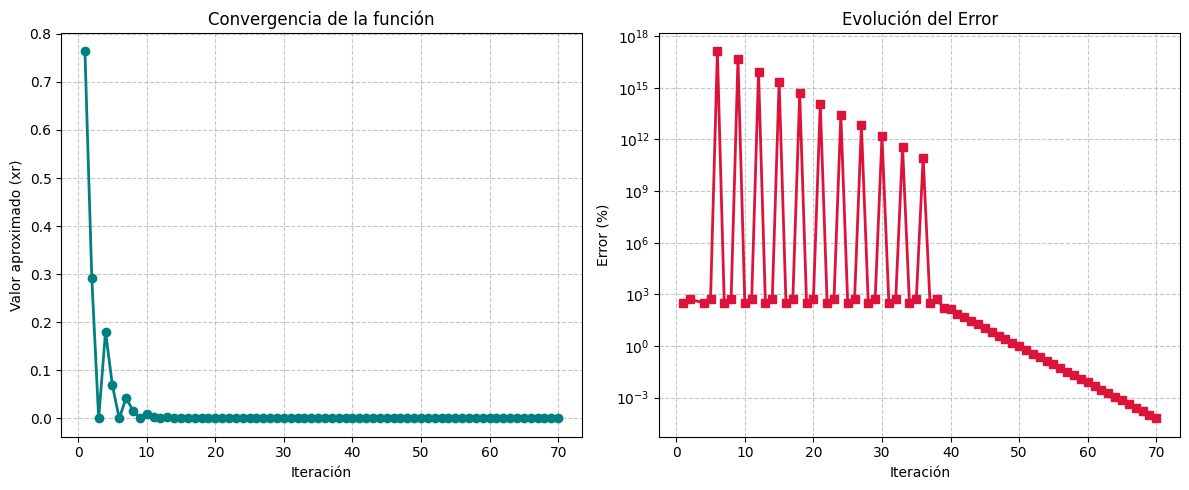

,Iteración,xl,xu,xr,f(x),Error
0,1,-4.721360e-01,2.000000e+00,7.639320e-01,8.111456,323.606798
1,2,-4.721360e-01,1.055728e+00,2.917961e-01,9.684265,523.606798
2,3,-4.721360e-01,4.721360e-01,0.000000e+00,10.000000,NaN
3,4,-1.114562e-01,4.721360e-01,1.803399e-01,9.875775,323.606798
4,5,-1.114562e-01,2.492236e-01,6.888371e-02,9.981347,523.606798
...,...,...,...,...,...,...
65,66,-1.490119e-08,-1.490112e-08,-1.490115e-08,10.000000,0.000432
66,67,-1.490116e-08,-1.490112e-08,-1.490114e-08,10.000000,0.000267
67,68,-1.490116e-08,-1.490114e-08,-1.490115e-08,10.000000,0.000165
68,69,-1.490116e-08,-1.490115e-08,-1.490115e-08,10.000000,0.000102


In [ ]:
def menu_interactivo():
    print(" MENÚ\n\n")

    # 1. Tolerancia y cantidad máxima de iteraciones
    try:
        es_in = input(f"1. Ingresa la tolerancia (Por defecto: {tolerancia}): ")
        es = float(es_in) if es_in.strip() else tolerancia

        imax_in = input(f"2. Ingresa el máximo de iteraciones (Por defecto: {imax}): ")
        iter_max = int(imax_in) if imax_in.strip() else imax
    except ValueError:
        print(f"\n[!] Error en formato. Se usarán valores por defecto (tolerancia={tolerancia}, imax={imax}).")
        es, iter_max = tolerancia, imax

    # 2. Selección del método
    print("\n--- SELECCIÓN DE MÉTODO ---")
    print("1. Bisección (Raíz)")
    print("2. Falsa Posición (Raíz)")
    print("3. Razón Dorada (Optimización)")
    print("4. Interpolación Cuadrática (Optimización)")
    print("5. Newton-Raphson (Raíz)")
    print("6. Newton (Optimización)")
    print("7. Búsqueda Aleatoria (Optimización)")

    metodo = input("Elige el número del método que deseas utilizar (1-7): ").strip()

    # Determinar modo si aplica
    modo = 'min'
    if metodo in ['3', '6', '7']:
        modo_in = input("Este es un método de optimización. ¿Buscar 'min' (mínimo) o 'max' (máximo)?: ").strip().lower()
        if modo_in in ['min', 'max']:
            modo = modo_in
        else:
            print(f"[!] Entrada inválida. Se buscará por defecto un '{modo}'.")

    # 3. Función y parámetros Específicos
    print("\n--- GUÍA DE SINTAXIS MATEMÁTICA ---")
    print(" • Variable obligatoria: 'x'")
    print(" • Operadores básicos:   +, -, *, /")
    print(" • Potencias:            ^  o  **  (Ej: x^2 o x**2)")
    print(" • Trigonométricas:      sin(x), cos(x), tan(x), arcsin(x)...")
    print(" • Logaritmos y exp:     log(x) [base e], log10(x), exp(x)")
    print(" • Raíces y Constantes:  sqrt(x), pi, e")
    print(" • Ejemplos válidos:     x^3 - 4*x + sin(pi*x)")
    print("                         exp(-x) * cos(x)")
    print("                         sqrt(x) + log(x)")

    print("\n--- FUNCIÓN MATEMÁTICA ---")
    f_str = input("Ingresa la función f(x): ")
    f = convertir_funcion(f_str)

    print("\n--- PARÁMETROS DEL MÉTODO ---")
    try:
        if metodo in ['1', '2', '3']:
            xl = float(input("Límite inferior (xl): "))
            xu = float(input("Límite superior (xu): "))

            if metodo == '1':
                res, df = biseccion(f, xl, xu, tolerancia=es, imax=iter_max)
            elif metodo == '2':
                res, df = falsa_posicion(f, xl, xu, tolerancia=es, imax=iter_max)
            elif metodo == '3':
                res, df = razon_dorada(f, xl, xu, tolerancia=es, imax=iter_max, modo=modo)

        elif metodo == '4':
            x0 = float(input("Punto inicial (x0): "))
            x1 = float(input("Punto intermedio (x1): "))
            x2 = float(input("Punto final (x2): "))
            res, df = interpolacion_cuadratica(f, x0, x1, x2, tolerancia=es, imax=iter_max)

        elif metodo == '5':
            df_str = input("Ingresa la primera derivada f'(x) (Ej: 2*x): ")
            f_deriv = convertir_funcion(df_str)
            x0 = float(input("Punto inicial (x0): "))
            res, df = newton_raphson(f, f_deriv, x0, tolerancia=es, imax=iter_max)

        elif metodo == '6':
            x0 = float(input("Punto inicial (x0): "))
            res, df = newton(f, x0, tolerancia=es, imax=iter_max, modo=modo)

        elif metodo == '7':
            a = float(input("Límite inferior (a): "))
            b = float(input("Límite superior (b): "))
            # En búsqueda aleatoria el parámetro se llama 'n', no 'imax'
            res, val, df = busqueda_aleatoria(f, a, b, n=iter_max, modo=modo)

        else:
            print("\n[!] Opción de método no válida. Ejecuta de nuevo.")

    except Exception as e:
        print(f"\n[!] Ocurrió un error al ejecutar el método: {e}")
        print("Revisa que los parámetros y la sintaxis de la función sean correctos.")

# Ejecutar el menú interactivo
menu_interactivo()